# 📧 KLASIFKASI EMAIL SPAM BAHASA INDONESIA MENGGUNAKAN ALGORITMA SPPORT VECTOR MACHINE

## Dataset Wanda:
- **email_spam_indo.csv** -

## Algoritma yang digunakan:
Support Vector Machine (SVM)

## Output:
- Model terbaik akan disimpan di folder `models/`

## 1. Import Data & Library

In [1]:
print("\nBismillah")


!pip install Sastrawi
!pip install wordcloud

import pandas as pd
import numpy as np
import re
import warnings

warnings.filterwarnings('ignore')


from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory


import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


from sklearn.feature_extraction.text import TfidfVectorizer


from sklearn.svm import LinearSVC


from sklearn.model_selection import StratifiedKFold


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report


import joblib

print("library sudah siap, lanjut proses...")



Bismillah
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.8 MB/s eta 0:00:00
library sudah siap, lanjut proses...


## 2. EDA (Exploratory Data Analysis)

Lihat Dataset

In [2]:
print("📂Mulai dataset...")

df = pd.read_csv('email_spam_indo.csv')

print("Total data:", len(df))
print("✅Data sudah masuk")

print("\n📊 Tampilan Dataset:")
df.head()

📂Mulai dataset...
Total data: 2636
✅Data sudah masuk

📊 Tampilan Dataset:


,Kategori,Pesan
0,spam,Secara alami tak tertahankan identitas perusah...
1,spam,Fanny Gunslinger Perdagangan Saham adalah Merr...
2,spam,Rumah -rumah baru yang luar biasa menjadi muda...
3,spam,4 Permintaan Khusus Pencetakan Warna Informasi...
4,spam,"Jangan punya uang, dapatkan CD perangkat lunak..."


Explore struktur kelas yaitu spam dan ham. Analisis Struktur Data

In [3]:

print("📊 DATASET EMAIL SPAM INDONESIA")
print("-" * 40)

print("Ukuran data:", df.shape)
print("\nKolom yang ada:", df.columns.tolist())

print("\nTipe data:")
print(df.dtypes)

print("\n Label:")
print(df['Kategori'].value_counts())
# pisahkan data
data_spam = df[df['Kategori'] == 'spam']
data_ham = df[df['Kategori'] == 'ham']



📊 DATASET EMAIL SPAM INDONESIA
----------------------------------------
Ukuran data: (2636, 2)

Kolom yang ada: ['Kategori', 'Pesan']

Tipe data:
Kategori    object
Pesan       object
dtype: object

 Label:
Kategori
spam    1368
ham     1268
Name: count, dtype: int64


Visualisasi data menggunakan grafik pie chart dan bar chart.

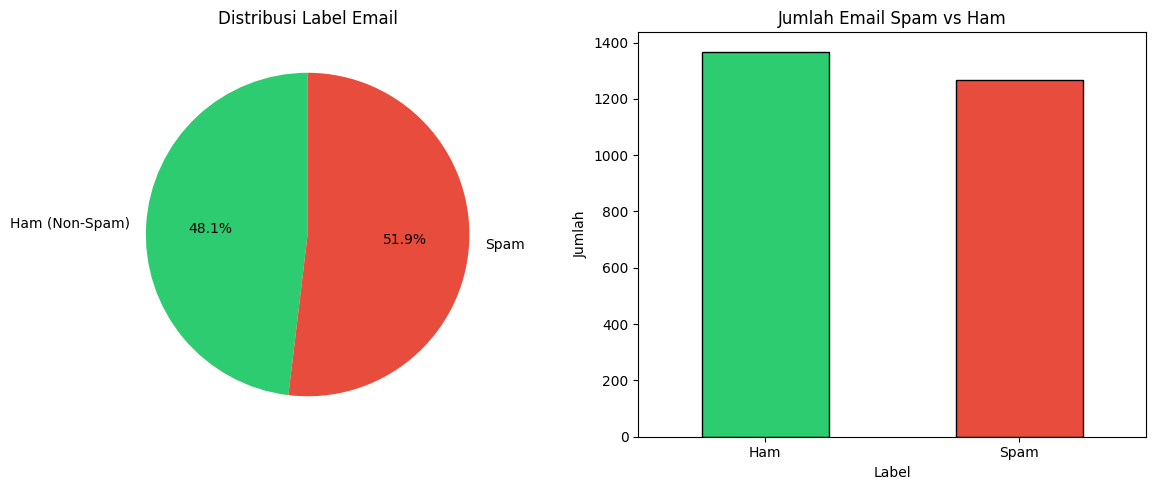

In [4]:
import matplotlib.pyplot as plt



fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2ecc71', '#e74c3c']
labels_pie = ['Ham (Non-Spam)', 'Spam']
sizes = df['Kategori'].value_counts().sort_index()

axes[0].pie(
    sizes,
    labels=labels_pie,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Distribusi Label Email')


df['Kategori'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    color=colors,
    edgecolor='black'
)

axes[1].set_title('Jumlah Email Spam vs Ham')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Jumlah')
axes[1].set_xticklabels(['Ham', 'Spam'], rotation=0)

plt.tight_layout()
plt.show()

## 3. Data Pra Pemrosesan


1. Pengecekan Data Kosong (Handle missing Values

In [5]:


print("📋 cek data kosong")
print("=" * 40)



if 'Kategori' in df.columns and 'label' not in df.columns:
    df.rename(columns={'Kategori': 'label'}, inplace=True)

if 'Pesan' in df.columns and 'body' not in df.columns:
    df.rename(columns={'Pesan': 'body'}, inplace=True)

print("\njumlah data kosong tiap kolom:")
print(df.isnull().sum())

print("\ntotal baris yang ada data kosong:", df.isnull().any(axis=1).sum())

df['body'] = df['body'].fillna('')

df['text'] = df['body']

print("\n✅ sudah ditangani, lanjut proses")
print("Text Cleaning:", df.shape)


📋 cek data kosong

jumlah data kosong tiap kolom:
label    0
body     0
dtype: int64

total baris yang ada data kosong: 0

✅ sudah ditangani, lanjut proses
Text Cleaning: (2636, 3)


2. Text cleaning & case Folding
Proses ini meliputi:

    *   Mengubah seluruh huruf menjadi huruf kecil (case folding)
    *   Menghapus URL
    *   Menghapus alamat email
    *   Menghapus tag HTML
    *   Menghapus tanda baca
    *   Menghapus angka
    *   Menghapus spasi berlebih

In [6]:
import string # Tambahkan ini

def Bersihkan_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

print("🧹Mulai bersihin teks...")
df['text_clean'] = df['text'].apply(Bersihkan_text)

print("\n📝 Contoh hasil text cleaning:")
print("-" * 60)
for i in range(2):
    print(f"Teks Dataset Asli Sebelum Cleaning: {df['text'].iloc[i][:200]}...")
    print(f"Teks Dataset Setelah Di cleaning: {df['text_clean'].iloc[i][:200]}...")
    print("-" * 60)


print("\n✅ Text cleaning selesai!")
df.head(2)


🧹Mulai bersihin teks...

📝 Contoh hasil text cleaning:
------------------------------------------------------------
Teks Dataset Asli Sebelum Cleaning: Secara alami tak tertahankan identitas perusahaan Anda sangat sulit untuk mengingat kembali perusahaan: pasar penuh dengan suqestions dan informasi yang sama -sama; Tapi logo yang menarik, statlonery ...
Teks Dataset Setelah Di cleaning: secara alami tak tertahankan identitas perusahaan anda sangat sulit untuk mengingat kembali perusahaan pasar penuh dengan suqestions dan informasi yang sama sama tapi logo yang menarik statlonery yang...
------------------------------------------------------------
Teks Dataset Asli Sebelum Cleaning: Fanny Gunslinger Perdagangan Saham adalah Merrill tetapi Muzo bukan Colza yang dicapai dan kedua dari belakang seperti Esmark Ramble yang Pepatah adalah Segovia Tidak Kelompok Cobalah Kansas Tanzania ...
Teks Dataset Setelah Di cleaning: fanny gunslinger perdagangan saham adalah merrill tetapi muzo bukan col

,label,body,text,text_clean
0,spam,Secara alami tak tertahankan identitas perusah...,Secara alami tak tertahankan identitas perusah...,secara alami tak tertahankan identitas perusah...
1,spam,Fanny Gunslinger Perdagangan Saham adalah Merr...,Fanny Gunslinger Perdagangan Saham adalah Merr...,fanny gunslinger perdagangan saham adalah merr...


3. Filtering

In [7]:
print("🔍 Filtering data...")
print("=" * 50)

# Jumlah sebelum
jumlah_sebelum = len(df)
print(f"Jumlah data sebelum filtering: {jumlah_sebelum}")

# Simpan contoh sebelum
print("\n📄 Contoh data sebelum filtering:")
print(df[['text_clean']].head(3))

# Filtering
df = df[df['text_clean'].str.len() > 10].reset_index(drop=True)

# Jumlah sesudah
jumlah_sesudah = len(df)
print(f"\nJumlah data setelah filtering: {jumlah_sesudah}")

# Hitung yang terhapus
print(f"Jumlah data yang dihapus: {jumlah_sebelum - jumlah_sesudah}")

# Contoh sesudah
print("\n📄 Contoh data setelah filtering:")
df.head(2)


🔍 Filtering data...
Jumlah data sebelum filtering: 2636

📄 Contoh data sebelum filtering:
                                          text_clean
0  secara alami tak tertahankan identitas perusah...
1  fanny gunslinger perdagangan saham adalah merr...
2  rumah rumah baru yang luar biasa menjadi mudah...

Jumlah data setelah filtering: 2634
Jumlah data yang dihapus: 2

📄 Contoh data setelah filtering:


,label,body,text,text_clean
0,spam,Secara alami tak tertahankan identitas perusah...,Secara alami tak tertahankan identitas perusah...,secara alami tak tertahankan identitas perusah...
1,spam,Fanny Gunslinger Perdagangan Saham adalah Merr...,Fanny Gunslinger Perdagangan Saham adalah Merr...,fanny gunslinger perdagangan saham adalah merr...


4. Tokenazing

In [8]:
print("✂️ Proses Tokenizing...")
print("=" * 50)


print("\n📄 Contoh sebelum tokenizing:")
for i in range(2):
    print(f"Teks ke-{i+1}: {df['text_clean'].iloc[i]}")
    print("-" * 50)

df['tokens'] = df['text_clean'].apply(lambda x: x.split())


print("\n📄 Contoh setelah tokenizing:")
for i in range(2):
    print(f"Token ke-{i+1}: {df['tokens'].iloc[i]}")
    print("-" * 50)
df.head(2)
print("\n✅ Tokenizing selesai!")
df.head(2)

✂️ Proses Tokenizing...

📄 Contoh sebelum tokenizing:
Teks ke-1: secara alami tak tertahankan identitas perusahaan anda sangat sulit untuk mengingat kembali perusahaan pasar penuh dengan suqestions dan informasi yang sama sama tapi logo yang menarik statlonery yang bergaya dan situs web yang luar biasa akan membuat tugas lebih mudah kami tidak berjanji bahwa havinq memesan iogo perusahaan anda akan secara otomatis menjadi dunia ieader itu isguite ciear bahwa tanpa produk yang baik organisasi bisnis yang efektif dan tujuan praktis itu akan menjadi pasar saat ini tetapi kami berjanji bahwa upaya pemasaran anda akan menjadi jauh lebih efektif berikut adalah daftar manfaat yang jelas kreativitas logo asli buatan tangan secara khusus dilakukan untuk mencerminkan citra perusahaan anda yang khas kenyamanan logo dan alat tulis disediakan dalam semua format mudah untuk gunakan sistem manajemen konten letsyou ubah konten situs web anda dan bahkan strukturnya ketepatan anda akan melihat draft log

,label,body,text,text_clean,tokens
0,spam,Secara alami tak tertahankan identitas perusah...,Secara alami tak tertahankan identitas perusah...,secara alami tak tertahankan identitas perusah...,"[secara, alami, tak, tertahankan, identitas, p..."
1,spam,Fanny Gunslinger Perdagangan Saham adalah Merr...,Fanny Gunslinger Perdagangan Saham adalah Merr...,fanny gunslinger perdagangan saham adalah merr...,"[fanny, gunslinger, perdagangan, saham, adalah..."


5. Stop removal

In [9]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

print("🧹 Stopword Removal...")
print("=" * 50)


factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())


def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopwords]


print("\n📄 Sebelum stopword:")
for i in range(2):
    print(df['tokens'].iloc[i])


df['tokens_stop'] = df['tokens'].apply(remove_stopwords)


print("\n📄 Setelah stopword:")
for i in range(2):
    print(df['tokens_stop'].iloc[i])

print("\n✅ Stopword removal selesai!")
df.head(2)

🧹 Stopword Removal...

📄 Sebelum stopword:
['secara', 'alami', 'tak', 'tertahankan', 'identitas', 'perusahaan', 'anda', 'sangat', 'sulit', 'untuk', 'mengingat', 'kembali', 'perusahaan', 'pasar', 'penuh', 'dengan', 'suqestions', 'dan', 'informasi', 'yang', 'sama', 'sama', 'tapi', 'logo', 'yang', 'menarik', 'statlonery', 'yang', 'bergaya', 'dan', 'situs', 'web', 'yang', 'luar', 'biasa', 'akan', 'membuat', 'tugas', 'lebih', 'mudah', 'kami', 'tidak', 'berjanji', 'bahwa', 'havinq', 'memesan', 'iogo', 'perusahaan', 'anda', 'akan', 'secara', 'otomatis', 'menjadi', 'dunia', 'ieader', 'itu', 'isguite', 'ciear', 'bahwa', 'tanpa', 'produk', 'yang', 'baik', 'organisasi', 'bisnis', 'yang', 'efektif', 'dan', 'tujuan', 'praktis', 'itu', 'akan', 'menjadi', 'pasar', 'saat', 'ini', 'tetapi', 'kami', 'berjanji', 'bahwa', 'upaya', 'pemasaran', 'anda', 'akan', 'menjadi', 'jauh', 'lebih', 'efektif', 'berikut', 'adalah', 'daftar', 'manfaat', 'yang', 'jelas', 'kreativitas', 'logo', 'asli', 'buatan', 'tangan',

,label,body,text,text_clean,tokens,tokens_stop
0,spam,Secara alami tak tertahankan identitas perusah...,Secara alami tak tertahankan identitas perusah...,secara alami tak tertahankan identitas perusah...,"[secara, alami, tak, tertahankan, identitas, p...","[alami, tak, tertahankan, identitas, perusahaa..."
1,spam,Fanny Gunslinger Perdagangan Saham adalah Merr...,Fanny Gunslinger Perdagangan Saham adalah Merr...,fanny gunslinger perdagangan saham adalah merr...,"[fanny, gunslinger, perdagangan, saham, adalah...","[fanny, gunslinger, perdagangan, saham, merril..."


5. Stemming

In [10]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

print("\n🌱 Stemming...")
print("=" * 50)


factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]


print("\n📄 Sebelum stemming:")
for i in range(2):
    print(df['tokens_stop'].iloc[i])


df['tokens_stem'] = df['tokens_stop'].apply(stemming)


print("\n📄 Setelah stemming:")
for i in range(2):
    print(df['tokens_stem'].iloc[i])

print("\n✅ Stemming selesai,Data siap untuk Di seimbangkan!!")
df.head(2)


🌱 Stemming...

📄 Sebelum stemming:
['alami', 'tak', 'tertahankan', 'identitas', 'perusahaan', 'sangat', 'sulit', 'mengingat', 'perusahaan', 'pasar', 'penuh', 'suqestions', 'informasi', 'sama', 'sama', 'logo', 'menarik', 'statlonery', 'bergaya', 'situs', 'web', 'luar', 'biasa', 'membuat', 'tugas', 'lebih', 'mudah', 'berjanji', 'havinq', 'memesan', 'iogo', 'perusahaan', 'otomatis', 'menjadi', 'dunia', 'ieader', 'isguite', 'ciear', 'produk', 'baik', 'organisasi', 'bisnis', 'efektif', 'tujuan', 'praktis', 'menjadi', 'pasar', 'berjanji', 'upaya', 'pemasaran', 'menjadi', 'jauh', 'lebih', 'efektif', 'berikut', 'daftar', 'manfaat', 'jelas', 'kreativitas', 'logo', 'asli', 'buatan', 'tangan', 'khusus', 'dilakukan', 'mencerminkan', 'citra', 'perusahaan', 'khas', 'kenyamanan', 'logo', 'alat', 'tulis', 'disediakan', 'semua', 'format', 'mudah', 'gunakan', 'sistem', 'manajemen', 'konten', 'letsyou', 'ubah', 'konten', 'situs', 'web', 'bahkan', 'strukturnya', 'ketepatan', 'melihat', 'draft', 'logo', '

,label,body,text,text_clean,tokens,tokens_stop,tokens_stem
0,spam,Secara alami tak tertahankan identitas perusah...,Secara alami tak tertahankan identitas perusah...,secara alami tak tertahankan identitas perusah...,"[secara, alami, tak, tertahankan, identitas, p...","[alami, tak, tertahankan, identitas, perusahaa...","[alami, tak, tahan, identitas, usaha, sangat, ..."
1,spam,Fanny Gunslinger Perdagangan Saham adalah Merr...,Fanny Gunslinger Perdagangan Saham adalah Merr...,fanny gunslinger perdagangan saham adalah merr...,"[fanny, gunslinger, perdagangan, saham, adalah...","[fanny, gunslinger, perdagangan, saham, merril...","[fanny, gunslinger, dagang, saham, merrill, mu..."


In [11]:
df.to_csv('email_spam_indo_prapemrosesan.csv', index=False)


## 4. Penyeimbangan Data 2500 (1250 Spam dan Ham) Balancing

In [15]:
from sklearn.utils import resample

print("⚖️ Proses Data Balancing...")
print("=" * 50)

# Pastikan label jadi string supaya filter '1' dan '0' sinkron
df['label'] = df['label'].astype(str)

df_spam = df[df['label'] == '1']
df_ham = df[df['label'] == '0']

print("Sebelum balancing:")
print(df['label'].value_counts())

df_spam_bal = resample(df_spam, replace=False, n_samples=1250, random_state=42)
df_ham_bal = resample(df_ham, replace=False, n_samples=1250, random_state=42)

df_balanced = pd.concat([df_spam_bal, df_ham_bal])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nSetelah balancing:")
print("Total data:", df_balanced.shape)
print(df_balanced['label'].value_counts())



⚖️ Proses Data Balancing...
Sebelum balancing:
label
1    1367
0    1267
Name: count, dtype: int64

Setelah balancing:
Total data: (2500, 7)
label
0    1250
1    1250
Name: count, dtype: int64


Grafik keseimbangan

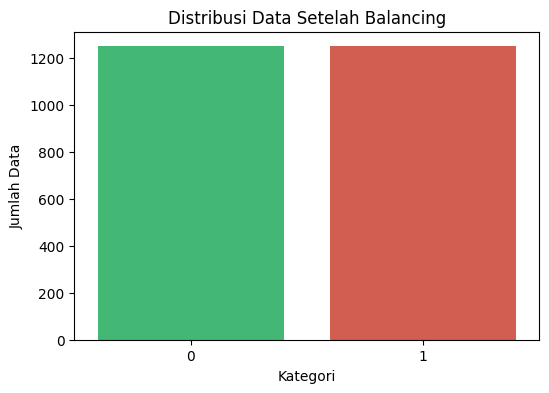

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    x="label",
    data=df_balanced,
    palette={'0': '#2ecc71', '1': '#e74c3c'}
)

plt.title("Distribusi Data Setelah Balancing")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Data")

plt.show()

## 5. Text Vectorization (TF-IDF)

TF-IDF (Term Frequency-Inverse Document Frequency) akan mengubah teks menjadi representasi numerik yang dapat diproses oleh model ML.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("🔢 Membuat TF-IDF Vectorizer...")

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2),
    stop_words=None,
    lowercase=True
)

# 🔥 PAKAI INI DULU BIAR AMAN
X = tfidf_vectorizer.fit_transform(df_balanced['text_clean'])
y = df_balanced['label'].map({'ham': 0, 'spam': 1})

y = df_balanced['label']

print("\n✅ TF-IDF Vectorization selesai!")
print("Shape:", X.shape)

🔢 Membuat TF-IDF Vectorizer...

✅ TF-IDF Vectorization selesai!
Shape: (2500, 10000)


## 6. Pengujian Model (K-Fold Cross Validation)

Manual split

*   Manual split
*   Validasi proporsi



In [20]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd

print("🔁 Pembagian data 5-Fold...")
print("=" * 50)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for i, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f"\n📂 Fold {i+1}")

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    print(f"Training: {X_train.shape[0]} | Testing: {X_test.shape[0]}")
    print("Distribusi training:")
    print(pd.Series(y_train).value_counts())
    print("Distribusi testing:")
    print(pd.Series(y_test).value_counts())

🔁 Pembagian data 5-Fold...

📂 Fold 1
Training: 2000 | Testing: 500
Distribusi training:
label
0    1000
1    1000
Name: count, dtype: int64
Distribusi testing:
label
0    250
1    250
Name: count, dtype: int64

📂 Fold 2
Training: 2000 | Testing: 500
Distribusi training:
label
0    1000
1    1000
Name: count, dtype: int64
Distribusi testing:
label
1    250
0    250
Name: count, dtype: int64

📂 Fold 3
Training: 2000 | Testing: 500
Distribusi training:
label
1    1000
0    1000
Name: count, dtype: int64
Distribusi testing:
label
0    250
1    250
Name: count, dtype: int64

📂 Fold 4
Training: 2000 | Testing: 500
Distribusi training:
label
0    1000
1    1000
Name: count, dtype: int64
Distribusi testing:
label
0    250
1    250
Name: count, dtype: int64

📂 Fold 5
Training: 2000 | Testing: 500
Distribusi training:
label
0    1000
1    1000
Name: count, dtype: int64
Distribusi testing:
label
1    250
0    250
Name: count, dtype: int64


In [21]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
import numpy as np

print("\n🔁 Evaluasi 5-Fold Cross Validation dengan SVM...")
print("=" * 50)

model = LinearSVC()

# akurasi tiap fold
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

print("\n📊 Hasil akurasi tiap fold:")
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}")

print(f"\n✅ Rata-rata akurasi: {np.mean(cv_scores):.4f}")


🔁 Evaluasi 5-Fold Cross Validation dengan SVM...

📊 Hasil akurasi tiap fold:
Fold 1: 0.9900
Fold 2: 0.9880
Fold 3: 0.9900
Fold 4: 0.9900
Fold 5: 0.9860

✅ Rata-rata akurasi: 0.9888


Prediksi Data

In [22]:

y_pred = cross_val_predict(model, X, y, cv=kf)

print("\n📋 Classification Report:")
print(classification_report(y, y_pred))


📋 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1250
           1       0.98      0.99      0.99      1250

    accuracy                           0.99      2500
   macro avg       0.99      0.99      0.99      2500
weighted avg       0.99      0.99      0.99      2500



## 7. Model Evaluation

In [26]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

print("📊 HASIL MODEL SVM (LinearSVC)")
print("=" * 60)


accuracy = np.mean(cv_scores)


svm_result = pd.DataFrame({
    'Model': ['SVM (LinearSVC)'],
    'Accuracy': [np.mean(cv_scores)],
    'Precision': [precision],
    'Recall': [recall],
    'F1-Score': [f1]
})



display(svm_result.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}'
}))

print("\n📋 Classification Report:")
print(classification_report(y, y_pred))

📊 HASIL MODEL SVM (LinearSVC)


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM (LinearSVC),0.9888,0.9842,0.9936,0.9889



📋 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1250
           1       0.98      0.99      0.99      1250

    accuracy                           0.99      2500
   macro avg       0.99      0.99      0.99      2500
weighted avg       0.99      0.99      0.99      2500



evaluasi

📊 Visualisasi Hasil Model SVM


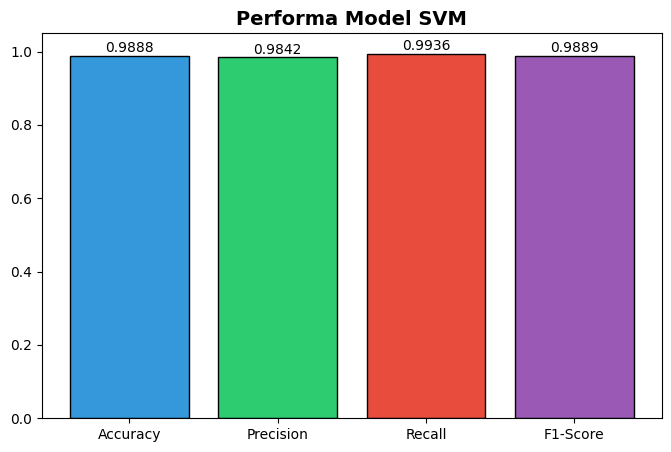

In [33]:
import matplotlib.pyplot as plt

print("📊 Visualisasi Hasil Model SVM")

# Ambil nilai dari hasil SVM
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [
    svm_result['Accuracy'][0],
    svm_result['Precision'][0],
    svm_result['Recall'][0],
    svm_result['F1-Score'][0]
]

# Warna (biru, hijau, merah, ungu)
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

# Plot
plt.figure(figsize=(8,5))
bars = plt.bar(metrics, values, color=colors, edgecolor='black')

# Judul
plt.title('Performa Model SVM', fontsize=14, fontweight='bold')
plt.ylim(0, 1.05)

# Label nilai di atas bar
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.4f}', ha='center')

plt.show()

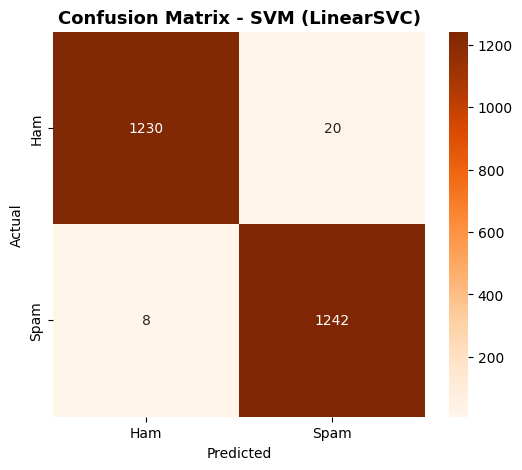

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title("Confusion Matrix - SVM (LinearSVC)", fontsize=13, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [40]:
from sklearn.metrics import classification_report

print("📋 Klasifikasi - SVM (LinearSVC)")
print("=" * 60)

print(classification_report(
    y, y_pred,
    target_names=['Ham (0)', 'Spam (1)']
))

📋 Klasifikasi - SVM (LinearSVC)
              precision    recall  f1-score   support

     Ham (0)       0.99      0.98      0.99      1250
    Spam (1)       0.98      0.99      0.99      1250

    accuracy                           0.99      2500
   macro avg       0.99      0.99      0.99      2500
weighted avg       0.99      0.99      0.99      2500



## 8. Simpan Model yang Telah Dilatih

Simpan model terbaik beserta vectorizer ke folder `models/` dengan format yang rapi dan timestamp.

In [43]:
import os
import joblib
import json
from datetime import datetime
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

print("💾 Menyimpan Model S...")

MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)


timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')


model_name = "SVM (LinearSVC)"
svm_model = model


model_filename = f'{MODEL_DIR}/svm_model_{timestamp}.joblib'
joblib.dump(svm_model, model_filename)


vectorizer_filename = f'{MODEL_DIR}/tfidf_vectorizer_{timestamp}.joblib'
joblib.dump(tfidf_vectorizer, vectorizer_filename)


# Use y_pred (which is already calculated in a previous cell) for metrics
model_metadata = {
    'model_name': model_name,
    'timestamp': timestamp,
    'metrics': {
        'accuracy': float(np.mean(cv_scores)),
        'precision': float(precision_score(y, y_pred, pos_label='1')),
        'recall': float(recall_score(y, y_pred, pos_label='1')),
        'f1_score': float(f1_score(y, y_pred, pos_label='1'))
    },
    'data_info': {
        'total_data': len(df),
        'num_features': X.shape[1]
    }
}


metadata_filename = f'{MODEL_DIR}/model_metadata_{timestamp}.json'
with open(metadata_filename, 'w') as f:
    json.dump(model_metadata, f, indent=4)

print(f"\n✅ Metadata disimpan: {metadata_filename}")

print(f"\n📂 Isi folder '{MODEL_DIR}':")
for file in os.listdir(MODEL_DIR):
    file_path = os.path.join(MODEL_DIR, file)
    size_kb = os.path.getsize(file_path) / 1024
    print(f"   📄 {file} ({size_kb:.2f} KB)")

💾 Menyimpan Model S...

✅ Metadata disimpan: models/model_metadata_20260411_071630.json

📂 Isi folder 'models':
   📄 model_metadata_20260411_071630.json (0.31 KB)
   📄 svm_model_20260411_071542.joblib (0.27 KB)
   📄 tfidf_vectorizer_20260411_070609.joblib (393.04 KB)
   📄 svm_model_20260411_065120.joblib (0.27 KB)
   📄 tfidf_vectorizer_20260411_071630.joblib (393.04 KB)
   📄 tfidf_vectorizer_20260411_071542.joblib (393.04 KB)
   📄 svm_model_20260411_071454.joblib (0.27 KB)
   📄 tfidf_vectorizer_20260411_071454.joblib (393.04 KB)
   📄 svm_model_20260411_070609.joblib (0.27 KB)
   📄 tfidf_20260411_065120.joblib (393.04 KB)
   📄 svm_model_20260411_071630.joblib (0.27 KB)


## 9. Load and Test Saved Model

Load model yang sudah disimpan dan test dengan contoh email baru.

In [45]:
# Load model dan vectorizer yang tersimpan
print("📥 Loading saved model and vectorizer...")

loaded_model = joblib.load(model_filename)
loaded_vectorizer = joblib.load(vectorizer_filename)

print(f"✅ Model loaded: {model_filename}")
print(f"✅ Vectorizer loaded: {vectorizer_filename}")

📥 Loading saved model and vectorizer...
✅ Model loaded: models/svm_model_20260411_071630.joblib
✅ Vectorizer loaded: models/tfidf_vectorizer_20260411_071630.joblib


In [46]:

def predict_email(email_text, model=None, vectorizer=None):
    """
    Memprediksi apakah sebuah email adalah spam atau bukan.

    Parameters:
    -----------
    email_text : str
        Teks email yang akan diprediksi
    model : sklearn model
        Model yang sudah di-train (default: loaded_model)
    vectorizer : TfidfVectorizer
        Vectorizer yang sudah di-fit (default: loaded_vectorizer)

    Returns:
    --------
    dict : Dictionary berisi hasil prediksi dan confidence
    """
    if model is None:
        model = loaded_model
    if vectorizer is None:
        vectorizer = loaded_vectorizer


    cleaned_text = clean_text(email_text)


    text_vectorized = vectorizer.transform([cleaned_text])


    prediction = model.predict(text_vectorized)[0]


    try:

        proba = model.predict_proba(text_vectorized)[0]
        confidence = max(proba) * 100
    except AttributeError:
        confidence = None

    result = {
        'text_preview': email_text[:100] + '...' if len(email_text) > 100 else email_text,
        'prediction': 'SPAM 🚫' if prediction == 'spam' else 'HAM ✅',
        'label': 1 if prediction == 'spam' else 0,
        'confidence': f'{confidence:.2f}%' if confidence else 'N/A'
    }

    return result

print("✅ Fungsi predict_email() siap digunakan!")

✅ Fungsi predict_email() siap digunakan!


## 10. Ringkasan & Kesimpulan

In [49]:

print("📊 RINGKASAN HASIL KLASIFIKASI EMAIL SPAM")


print(f"""
📌 Informasi Dataset:
   • Total email yang diproses: {len(df)}
   • Data training: {X_train.shape[0]}
   • Data testing: {X_test.shape[0]}
   • Jumlah fitur (TF-IDF): {X.shape[1]}

🏆 Model yang Digunakan: SVM (LinearSVC)
   • Akurasi: {accuracy:.4f} ({accuracy*100:.2f}%)
   • Precision: {precision:.4f}
   • Recall: {recall:.4f}
   • F1-Score: {f1:.4f}
   • Nilai Cross-Validation: {np.mean(cv_scores):.4f}

📁 File yang Disimpan (folder 'models/'):
   • Model: {model_filename}
   • Vectorizer: {vectorizer_filename}
   • Metadata: {metadata_filename}

🚀 Contoh Penggunaan:

   model = joblib.load('{model_filename}')
   vectorizer = joblib.load('{vectorizer_filename}')


   text = "Selamat! Anda mendapatkan hadiah jutaan rupiah!"
   text_vec = vectorizer.transform([text])
   hasil = model.predict(text_vec)
   print("Hasil Prediksi:", "Spam" if hasil[0]==1 else "Ham")
""")


print("✅ Proses klasifikasi selesai!")


📊 RINGKASAN HASIL KLASIFIKASI EMAIL SPAM

📌 Informasi Dataset:
   • Total email yang diproses: 2634
   • Data training: 2000
   • Data testing: 500
   • Jumlah fitur (TF-IDF): 10000

🏆 Model yang Digunakan: SVM (LinearSVC)
   • Akurasi: 0.9888 (98.88%)
   • Precision: 0.9842
   • Recall: 0.9936
   • F1-Score: 0.9889
   • Nilai Cross-Validation: 0.9888

📁 File yang Disimpan (folder 'models/'):
   • Model: models/svm_model_20260411_071630.joblib
   • Vectorizer: models/tfidf_vectorizer_20260411_071630.joblib
   • Metadata: models/model_metadata_20260411_071630.json

🚀 Contoh Penggunaan:

   model = joblib.load('models/svm_model_20260411_071630.joblib')
   vectorizer = joblib.load('models/tfidf_vectorizer_20260411_071630.joblib')
   

   text = "Selamat! Anda mendapatkan hadiah jutaan rupiah!"
   text_vec = vectorizer.transform([text])
   hasil = model.predict(text_vec)
   print("Hasil Prediksi:", "Spam" if hasil[0]==1 else "Ham")

✅ Proses klasifikasi selesai!
